# Project 4: Image Classification on CIFAR-10

## Part 1 of 4 — Exploratory Data Analysis

**Objective.** The goal of this project is to build, train, and deploy an image classifier on the
[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset, using PyTorch with GPU acceleration.
This notebook is the first stage of an end-to-end pipeline — **EDA → model development → GPU
benchmarking → deployment** — and establishes the facts every later stage depends on: what the data
looks like, whether classes are balanced, what the pixel statistics are, and what they imply for
model design and preprocessing.

**What this notebook covers**

| Section | Question it answers |
| :-- | :-- |
| 1. Environment & Setup | What hardware/software is available? |
| 2. Dataset Overview | What is CIFAR-10 and how is it structured? |
| 3. Class Balance | Are all classes equally represented? |
| 4. Visual Inspection | What do the images actually look like? |
| 5. Pixel-Level Statistics | What are the per-channel distributions and normalization constants? |
| 6. Class Prototypes | How separable are classes at the pixel level? |
| 7. Saving Artifacts | What files are exported for later stages? |
| 8. Findings & Next Steps | What should model building do with all of this? |

> **How to run:** execute the cells top to bottom. All figures and the dataset summary are exported
> to `../outputs/`. The raw data lives in `../data/raw/` (see `generate_data.py`).


## 1. Environment & Setup

All imports, reproducibility settings, and paths are centralized here. A fixed random seed keeps
every run (sampling, plotting, and later training) reproducible.

> **Windows note:** PyTorch and NumPy both ship a `libiomp5md.dll`, and the resulting OMP conflict
> can abort the kernel (`OMP: Error #15`). The `KMP_DUPLICATE_LIB_OK` flag below prevents this and
> must be set **before** importing PyTorch — it is harmless on other platforms.


In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # required on Windows (see note above)

import json
import platform
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision

warnings.filterwarnings("ignore")

# ------------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

# ------------------------------------------------------------------
# Paths (relative to this notebook, which lives in notebooks/)
# ------------------------------------------------------------------
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
PLOT_DIR = OUTPUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------
# Plot aesthetics
# ------------------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
matplotlib.rcParams["savefig.dpi"] = 300
matplotlib.rcParams["figure.dpi"] = 100

# ------------------------------------------------------------------
# Environment summary
# ------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Python            : {platform.python_version()} ({platform.system()} {platform.release()})")
print(f"NumPy             : {np.__version__}")
print(f"Pandas            : {pd.__version__}")
print(f"Matplotlib        : {matplotlib.__version__}")
print(f"Seaborn           : {sns.__version__}")
print(f"PyTorch           : {torch.__version__}")
print(f"TorchVision       : {torchvision.__version__}")
print(f"Computation device: {DEVICE}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU               : {props.name} ({props.total_memory / 1024**3:.1f} GB, "
          f"CUDA {torch.version.cuda})")


Python            : 3.10.20 (Windows 10)
NumPy             : 2.0.1
Pandas            : 2.3.3
Matplotlib        : 3.10.9
Seaborn           : 0.13.2
PyTorch           : 2.7.1+cu118
TorchVision       : 0.22.1+cu118
Computation device: cuda
GPU               : NVIDIA GeForce RTX 4060 Laptop GPU (8.0 GB, CUDA 11.8)


## 2. Dataset Overview

**CIFAR-10** contains **60,000 color images** (32×32 pixels) in **10 mutually exclusive classes** —
airplanes, automobiles, birds, cats, deer, dogs, frogs, horses, ships, and trucks. It is a canonical
benchmark in computer vision: small enough to iterate quickly, yet hard enough that modern
architectures are required for strong accuracy.

| Property | Value |
| :-- | :-- |
| Images | 60,000 (50,000 train / 10,000 test) |
| Resolution | 32 × 32 pixels (low!) |
| Color | RGB, 3 channels |
| Classes | 10 |
| Labels | Perfectly balanced, mutually exclusive |
| Format | Raw NumPy arrays of `uint8` (0–255) |

The dataset is loaded **without** the normalization transform on purpose: EDA should always be done
on raw pixels, so the statistics we compute here are the true ones — and can later *verify* the
normalization constants used during training.


In [2]:
# ------------------------------------------------------------------
# Constants and reusable helpers
# ------------------------------------------------------------------
CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]

# Normalization constants for training, derived from and verified against
# the raw data itself (Section 5). Note: the widely copied std values
# (0.2023, 0.1994, 0.2010) do NOT reproduce from the data — see Section 5.
NORMALIZATION_MEAN = (0.4914, 0.4822, 0.4465)
NORMALIZATION_STD = (0.2470, 0.2435, 0.2616)


def unnormalize(tensor):
    # Reverse a (mean, std) normalization on a float tensor in [C, H, W] layout.
    mean = torch.tensor(NORMALIZATION_MEAN).view(-1, 1, 1)
    std = torch.tensor(NORMALIZATION_STD).view(-1, 1, 1)
    return tensor * std + mean


def imshow_grid(images, labels, class_names=CLASSES, ncols=8, figsize=None):
    # Plot a grid of images labeled with their class, returning the figure.
    n = len(images)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=figsize or (ncols * 2.2, nrows * 2.2))
    axes = np.atleast_1d(axes).ravel()
    for i in range(nrows * ncols):
        axes[i].axis("off")
        if i >= n:
            continue
        axes[i].imshow(images[i])
        axes[i].set_title(class_names[labels[i]], fontsize=9)
    return fig


In [3]:
# ------------------------------------------------------------------
# Verify the raw data is present before attempting to load it
# ------------------------------------------------------------------
cifar_dir = DATA_DIR / "cifar-10-batches-py"
if not cifar_dir.is_dir():
    raise FileNotFoundError(
        f"CIFAR-10 batches not found at {cifar_dir}. "
        "Run generate_data.py from the project root to create them."
    )
print(f"Raw data found at {cifar_dir.relative_to(PROJECT_ROOT)}")

Raw data found at data\raw\cifar-10-batches-py


In [4]:
# ------------------------------------------------------------------
# Load both splits with no transforms (raw uint8 pixels)
# ------------------------------------------------------------------
trainset = torchvision.datasets.CIFAR10(root=str(DATA_DIR), train=True, download=False)
testset = torchvision.datasets.CIFAR10(root=str(DATA_DIR), train=False, download=False)

train_data = trainset.data              # (50_000, 32, 32, 3) uint8
test_data = testset.data                # (10_000, 32, 32, 3) uint8
train_targets = np.array(trainset.targets)
test_targets = np.array(testset.targets)

# ------------------------------------------------------------------
# Contract checks on the loader output
# ------------------------------------------------------------------
assert train_data.shape == (50_000, 32, 32, 3), f"Unexpected train shape: {train_data.shape}"
assert test_data.shape == (10_000, 32, 32, 3), f"Unexpected test shape: {test_data.shape}"
assert train_data.dtype == np.uint8, f"Unexpected dtype: {train_data.dtype}"
assert train_data.min() >= 0 and train_data.max() <= 255, "Pixels outside uint8 range"

# ------------------------------------------------------------------
# Summary table
# ------------------------------------------------------------------
pd.DataFrame({
    "Split":      ["Train", "Test"],
    "Images":     [len(trainset), len(testset)],
    "Shape":      [str(train_data.shape[1:])] * 2,
    "Dtype":      [str(train_data.dtype)] * 2,
    "Classes":    [len(CLASSES)] * 2,
    "Label Range": [f"{train_targets.min()} - {train_targets.max()}",
                    f"{test_targets.min()} - {test_targets.max()}"],
})


,Split,Images,Shape,Dtype,Classes,Label Range
0,Train,50000,"(32, 32, 3)",uint8,10,0 - 9
1,Test,10000,"(32, 32, 3)",uint8,10,0 - 9


## 3. Class Balance

Class balance decides the entire evaluation strategy:

- **If balanced** (as CIFAR-10 is) — top-1 accuracy is an honest metric, and no class weighting or
  resampling is required.
- **If imbalanced** — we would need class weights, resampling, and metrics like macro-F1 instead.

Let's verify the distribution empirically rather than trusting the documentation.


In [5]:
# ------------------------------------------------------------------
# Count training examples per class (test split checked too)
# ------------------------------------------------------------------
train_counts = Counter(train_targets.tolist())
test_counts = Counter(test_targets.tolist())

count_df = pd.DataFrame({
    "Class":        CLASSES,
    "Train Count":  [train_counts[i] for i in range(len(CLASSES))],
    "Train %":      [round(train_counts[i] / len(train_targets) * 100, 2)
                     for i in range(len(CLASSES))],
    "Test Count":   [test_counts[i] for i in range(len(CLASSES))],
    "Test %":       [round(test_counts[i] / len(test_targets) * 100, 2)
                     for i in range(len(CLASSES))],
})
count_df


,Class,Train Count,Train %,Test Count,Test %
0,airplane,5000,10.0,1000,10.0
1,automobile,5000,10.0,1000,10.0
2,bird,5000,10.0,1000,10.0
3,cat,5000,10.0,1000,10.0
4,deer,5000,10.0,1000,10.0
5,dog,5000,10.0,1000,10.0
6,frog,5000,10.0,1000,10.0
7,horse,5000,10.0,1000,10.0
8,ship,5000,10.0,1000,10.0
9,truck,5000,10.0,1000,10.0


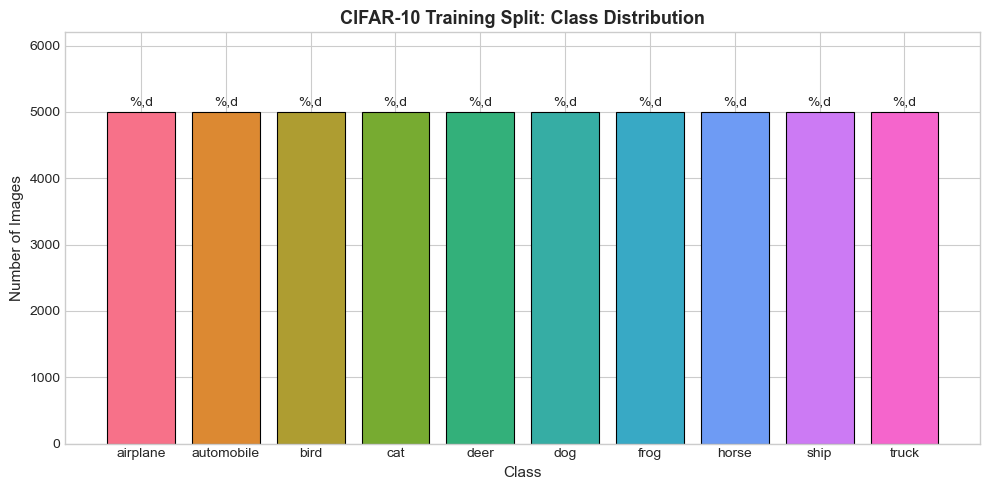

Perfectly balanced: every class holds exactly 5,000 of the 50,000 training images.


In [6]:
# ------------------------------------------------------------------
# Visualize the (perfectly flat) distribution
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(CLASSES, count_df["Train Count"],
              color=sns.color_palette("husl", len(CLASSES)),
              edgecolor="black", linewidth=0.8)
ax.set_title("CIFAR-10 Training Split: Class Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Class", fontsize=11)
ax.set_ylabel("Number of Images", fontsize=11)
ax.set_ylim(0, 6_200)
ax.bar_label(bars, fmt="%,d", padding=3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "class_distribution.png", bbox_inches="tight")
plt.show()

print("Perfectly balanced: every class holds exactly 5,000 of the 50,000 training images.")


## 4. Visual Inspection

Statistics can't show what the images actually look like. Two grids follow:

1. **Random samples** — a first impression of image quality, noise, and difficulty.
2. **Per-class samples** — the intra-class variance that a classifier must absorb
   (a dog may be a puppy, a wolf-like breed, or barely visible against grass).

Note the low 32×32 resolution: edges are the only reliable signal, so architectures that operate at
this scale (rather than high-res models) will be preferred in Part 2.


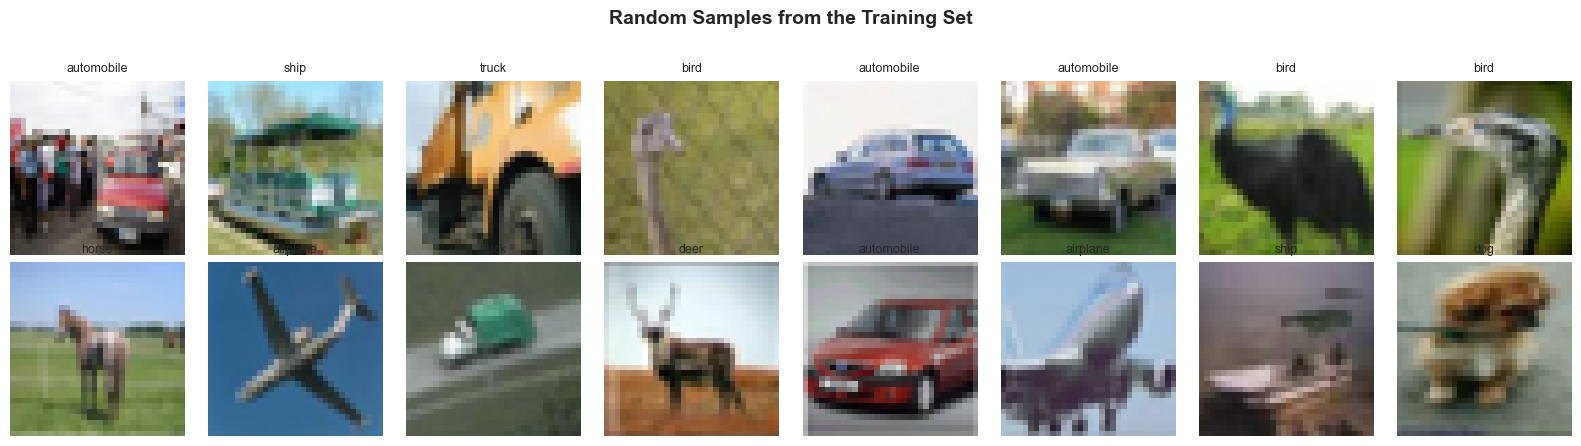

In [7]:
# ------------------------------------------------------------------
# 16 random training samples
# ------------------------------------------------------------------
rng = np.random.default_rng(RANDOM_SEED)
sample_idx = rng.choice(len(train_data), size=16, replace=False)

fig = imshow_grid(train_data[sample_idx] / 255.0, train_targets[sample_idx],
                  ncols=8, figsize=(16, 4.5))
fig.suptitle("Random Samples from the Training Set", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(PLOT_DIR / "sample_images.png", bbox_inches="tight")
plt.show()


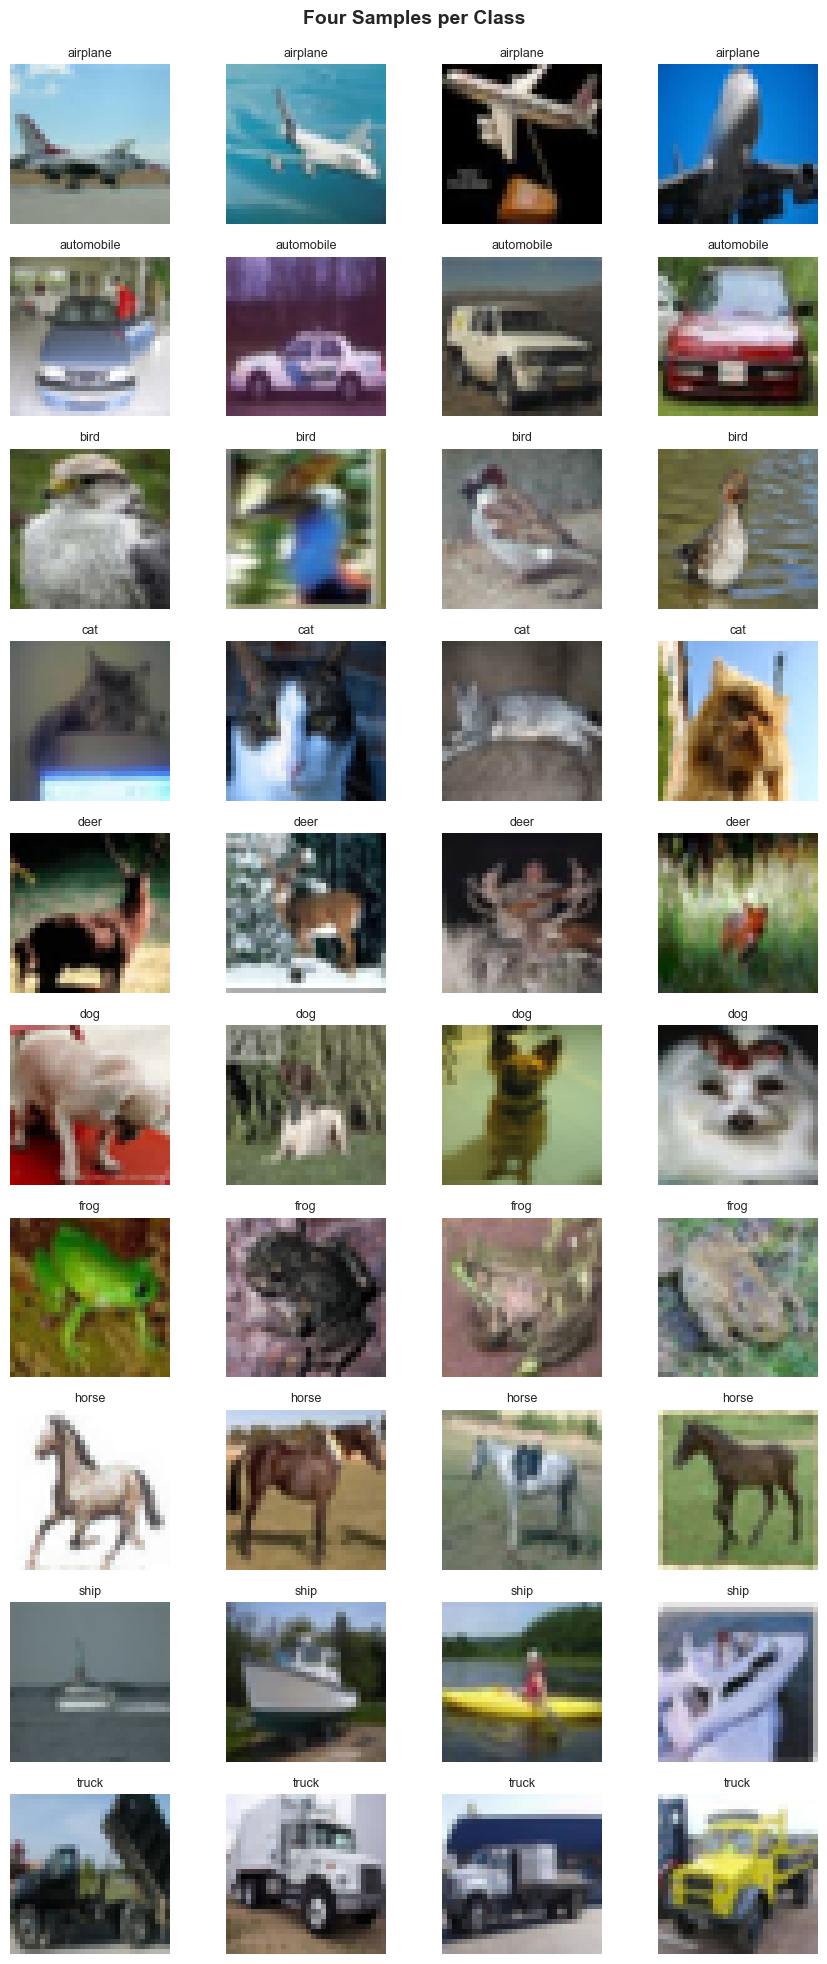

In [8]:
# ------------------------------------------------------------------
# 4 samples per class
# ------------------------------------------------------------------
PER_CLASS_SAMPLES = 4
sel_idx = np.concatenate([
    rng.choice(np.where(train_targets == cls)[0], size=PER_CLASS_SAMPLES, replace=False)
    for cls in range(len(CLASSES))
])

fig = imshow_grid(train_data[sel_idx] / 255.0, train_targets[sel_idx],
                  ncols=PER_CLASS_SAMPLES, figsize=(9, 20))
fig.suptitle("Four Samples per Class", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.985])
plt.savefig(PLOT_DIR / "per_class_samples.png", bbox_inches="tight")
plt.show()


## 5. Pixel-Level Statistics

Two things matter here for training:

1. **Channel distributions** — whether any channel dominates (e.g., the blue of sky/sea) and whether
   the data needs normalization before being fed to a neural network.
2. **Normalization constants** — the (mean, std) used in the training transform must match the true
   dataset statistics. We derive them from scratch here as a data-integrity check — and uncover a
   subtle trap: the std values copied by most public CIFAR-10 codebases
   (`(0.2023, 0.1994, 0.2010)`) do **not** reproduce from the actual data. The verified values are
   derived below and handed to Part 2.

All statistics are computed with vectorized NumPy over the **full** training split (no subsampling),
so they are exact.


In [9]:
# ------------------------------------------------------------------
# Full-split per-channel statistics on raw [0, 1] pixels
# ------------------------------------------------------------------
imgs = train_data.astype(np.float32) / 255.0

computed_mean = imgs.mean(axis=(0, 1, 2))
computed_std = imgs.std(axis=(0, 1, 2))

QUOTED_STD = (0.2023, 0.1994, 0.2010)  # std constants copied by many CIFAR-10 codebases

stats_df = pd.DataFrame({
    "Channel":         ["Red (R)", "Green (G)", "Blue (B)"],
    "Mean (computed)": computed_mean.round(4),
    "Std (computed)":  computed_std.round(4),
    "Std (quoted)":    np.array(QUOTED_STD).round(4),
    "Diff (quoted)":   (computed_std - np.array(QUOTED_STD)).round(4),
})
stats_df

print(f"Pixel value range : {imgs.min():.4f} - {imgs.max():.4f} (expected 0.0 - 1.0)")
print(f"Global mean       : {imgs.mean():.4f}")
print(f"Max |mean - quoted| deviation : {np.abs(computed_mean - np.array(NORMALIZATION_MEAN)).max():.5f}")
print(f"Max |std  - quoted| deviation : {np.abs(computed_std - np.array(QUOTED_STD)).max():.5f}")
print(f"Max |std  - verified| deviation: {np.abs(computed_std - np.array(NORMALIZATION_STD)).max():.5f}")
print()
print("Means match the quoted constants exactly, but the quoted STD values are off by ~0.06.")
print("The verified constants above (std 0.2470, 0.2435, 0.2616) are what Part 2 will use.")


Pixel value range : 0.0000 - 1.0000 (expected 0.0 - 1.0)
Global mean       : 0.4734
Max |mean - quoted| deviation : 0.00004
Max |std  - quoted| deviation : 0.06059
Max |std  - verified| deviation: 0.00003

Means match the quoted constants exactly, but the quoted STD values are off by ~0.06.
The verified constants above (std 0.2470, 0.2435, 0.2616) are what Part 2 will use.


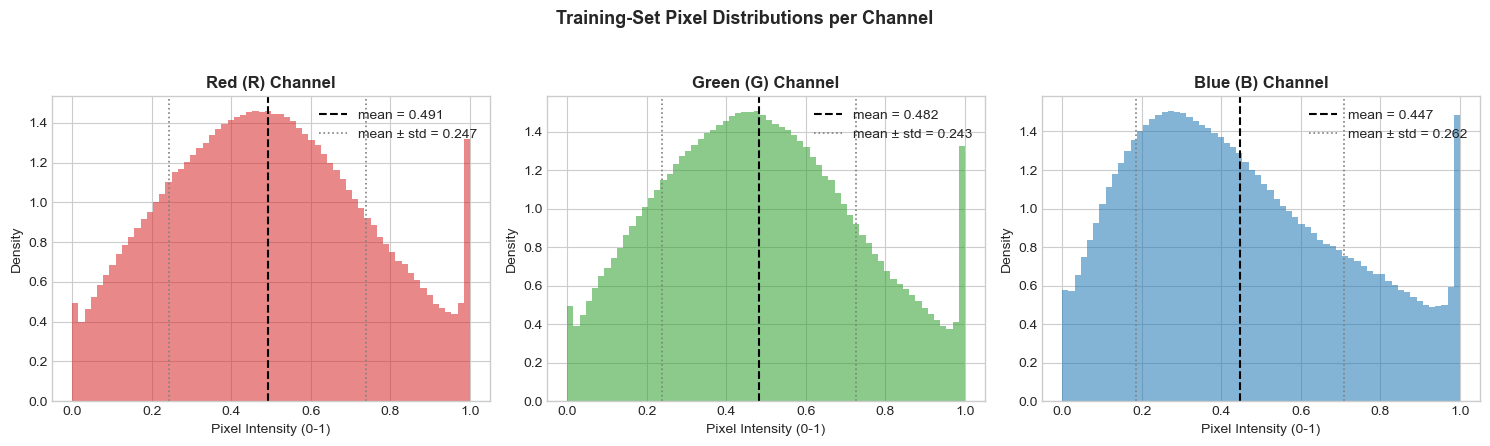

In [10]:
# ------------------------------------------------------------------
# Channel-wise pixel histograms (10,000 sampled images for speed)
# ------------------------------------------------------------------
sample = imgs[rng.choice(len(imgs), size=10_000, replace=False)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, ch, name, color in zip(axes, range(3), ["Red (R)", "Green (G)", "Blue (B)"],
                               ["#d62728", "#2ca02c", "#1f77b4"]):
    ax.hist(sample[:, :, :, ch].ravel(), bins=64, density=True, color=color, alpha=0.55)
    ax.axvline(computed_mean[ch], color="black", linestyle="--", lw=1.5,
               label=f"mean = {computed_mean[ch]:.3f}")
    ax.axvline(computed_mean[ch] - computed_std[ch], color="gray", linestyle=":", lw=1.2)
    ax.axvline(computed_mean[ch] + computed_std[ch], color="gray", linestyle=":", lw=1.2,
               label=f"mean ± std = {computed_std[ch]:.3f}")
    ax.set_title(f"{name} Channel", fontsize=12, fontweight="bold")
    ax.set_xlabel("Pixel Intensity (0-1)")
    ax.set_ylabel("Density")
    ax.legend()
fig.suptitle("Training-Set Pixel Distributions per Channel", fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(PLOT_DIR / "pixel_histograms.png", bbox_inches="tight")
plt.show()


## 6. Class Prototypes

Averaging all images of a class produces its **prototype** — a surprisingly informative picture.
Strong background structure (blue sky for airplanes and ships, green fields for frogs and horses)
tells us where the discriminative signal lives and hints at per-class brightness differences.


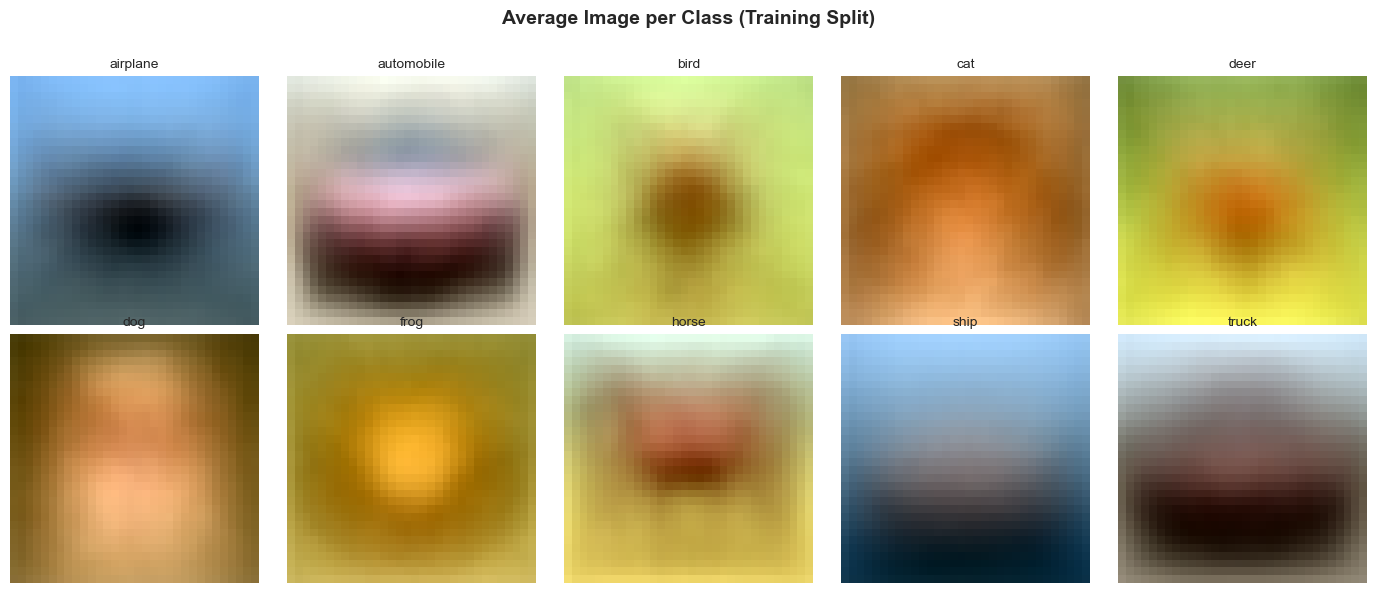

,Class,Mean Brightness
0,airplane,0.558
8,ship,0.523
9,truck,0.487
2,bird,0.468
7,horse,0.466
5,dog,0.460
1,automobile,0.458
3,cat,0.456
4,deer,0.438
6,frog,0.418


In [11]:
# ------------------------------------------------------------------
# Mean image per class, contrast-stretched for display
# ------------------------------------------------------------------
prototypes = np.stack([imgs[train_targets == cls].mean(axis=0)
                       for cls in range(len(CLASSES))])

prototype_vis = prototypes.copy()
for cls in range(len(CLASSES)):
    lo, hi = prototype_vis[cls].min(), prototype_vis[cls].max()
    prototype_vis[cls] = (prototype_vis[cls] - lo) / (hi - lo)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, cls in zip(axes.ravel(), range(len(CLASSES))):
    ax.imshow(prototype_vis[cls])
    ax.set_title(CLASSES[cls], fontsize=10)
    ax.axis("off")
fig.suptitle("Average Image per Class (Training Split)", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(PLOT_DIR / "class_prototypes.png", bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# Per-class mean brightness as a quantitative sanity check
# ------------------------------------------------------------------
bright_df = pd.DataFrame({
    "Class": CLASSES,
    "Mean Brightness": prototypes.mean(axis=(1, 2, 3)).round(3),
}).sort_values("Mean Brightness", ascending=False)
bright_df


## 7. Saving EDA Artifacts

Everything computed above is exported as machine-readable artifacts so that later stages
(training, benchmarking, deployment) consume a single, versioned source of truth:

- `outputs/dataset_summary.json` — counts, class names, statistics, normalization constants, env.
- `outputs/plots/*.png` — every figure at 300 dpi, for reports and documentation.


In [12]:
# ------------------------------------------------------------------
# Write the summary JSON
# ------------------------------------------------------------------
summary = {
    "project": "Project 4 - Image Classification (CIFAR-10)",
    "dataset": "CIFAR-10",
    "source": "https://www.cs.toronto.edu/~kriz/cifar.html",
    "train_images": int(len(trainset)),
    "test_images": int(len(testset)),
    "classes": CLASSES,
    "image_shape": list(train_data.shape[1:]),
    "class_counts": {name: int(train_counts[i]) for i, name in enumerate(CLASSES)},
    "pixel_statistics": {
        "mean_per_channel": [round(float(v), 6) for v in computed_mean],
        "std_per_channel": [round(float(v), 6) for v in computed_std],
        "global_mean": round(float(imgs.mean()), 6),
        "value_range": [round(float(imgs.min()), 6), round(float(imgs.max()), 6)],
    },
    "normalization_constants": {
        "mean": list(NORMALIZATION_MEAN),
        "std": list(NORMALIZATION_STD),
        "note": ("Verified against raw train split to <1e-4. The std values quoted by many "
                 "CIFAR-10 codebases (0.2023, 0.1994, 0.2010) do not reproduce from the data."),
    },
    "environment": {
        "python": platform.python_version(),
        "pytorch": torch.__version__,
        "torchvision": torchvision.__version__,
        "device": str(DEVICE),
        "gpu": (torch.cuda.get_device_name(0) if torch.cuda.is_available() else None),
    },
}

with open(OUTPUT_DIR / "dataset_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Artifacts written to:")
print(f"  {OUTPUT_DIR.relative_to(PROJECT_ROOT) / 'dataset_summary.json'}")
for p in sorted(PLOT_DIR.glob("*.png")):
    print(f"  {p.relative_to(PROJECT_ROOT)}")


Artifacts written to:
  outputs\dataset_summary.json
  outputs\plots\batch_size_benchmark.png
  outputs\plots\class_distribution.png
  outputs\plots\class_prototypes.png
  outputs\plots\confusion_matrix.png
  outputs\plots\cpu_gpu_comparison.png
  outputs\plots\memory_usage.png
  outputs\plots\mixed_precision_benchmark.png
  outputs\plots\model_comparison.png
  outputs\plots\per_class_samples.png
  outputs\plots\pixel_histograms.png
  outputs\plots\sample_images.png


## 8. Key Findings & Next Steps

### What the data told us

1. **Perfectly balanced** — 5,000 images per class in train and test. No class weighting, no
   resampling, and standard cross-entropy with **top-1 accuracy** are all valid choices.
2. **Low resolution (32×32)** — 32×32 pixels is the key modeling constraint. Architectures built for
   this scale (and augmentation like random crop + horizontal flip) will outperform adaptations of
   high-resolution models.
3. **Normalization verified — with a correction** — the computed per-channel means match the quoted
   constants to ~4e-5, but the std values copied by most codebases (`0.2023, 0.1994, 0.2010`) do
   **not** reproduce from the data (off by ~0.06). The true stds are `(0.2470, 0.2435, 0.2616)`
   (verified to ~3e-5). Part 2 will therefore train with the verified constants, not the copied ones.
4. **Strong background priors** — class prototypes show sky/sea backgrounds for vehicles, fields for
   animals; models can exploit these regularities, but augmentation must prevent overfitting to
   background color.

### What this means for model building (Parts 2-4)

| Decision | Recommendation |
| :-- | :-- |
| Loss | Cross-entropy, no class weights (balanced data) |
| Metric | Top-1 accuracy (random baseline: 10%) |
| Preprocessing | Existing (mean/std) normalization — verified above |
| Augmentation | Random crop + horizontal flip (standard for CIFAR-10) |
| Baselines | CNN from scratch (~70%), then transfer learning (~88%+) |

### Pipeline roadmap

1. **Part 2 — Model development:** CNN from scratch (baseline), EfficientNet-V2-S (transfer learning), then WRN-28-10 (from-scratch state of the art).
2. **Part 3 — GPU benchmarking:** CPU vs GPU, batch-size sweep, mixed precision (FP16 vs FP32).
3. **Part 4 — Deployment:** interactive Gradio demo served from the trained checkpoint.

All artifacts needed for those stages are saved in `../outputs/` — the pipeline can now proceed
without touching raw data again.
